In [138]:
import numpy as np
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

In [139]:
df = pd.read_csv('../data/interim/olist_ml_processed_dataset.csv')

In [140]:
# Mapping dictionary for your classes
status_mapping = {
    'Very Early': 0,
    'Somewhat Early': 1,
    'Early': 2,
    'On Time': 3,
    'Somewhat Late': 4,
    'Very Late': 5
}
df['delivery_label'] = df['delivery_status'].map(status_mapping)

In [141]:
X_raw = df.drop(columns=['actual_delivery_days', 'delivery_status', 'delivery_label']).values
y_raw = df['delivery_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Features go to float32; labels go to long (integers) for CrossEntropyLoss
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# --- Step 4: Create DataLoaders ---
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 256  # Adjust this depending on your preferences

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True          # Shuffle training data to help generalization
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False          # No need to shuffle test/evaluation data
)

print(f"DataLoaders successfully created!")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

DataLoaders successfully created!
Train batches: 271 | Test batches: 68


In [142]:
class RegularizedDeepClassifier(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.2):
        super(RegularizedDeepClassifier, self).__init__()
        
        # Define the 5 Hidden Layers
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 6)
        
        # Activations and Regularization
        self.gelu = nn.GELU()
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_rate)
        
        # Apply Xavier Initialization immediately to all linear layers
        self._init_weights()
        
    def _init_weights(self):
        # Loop through all layers of the model
        for name, module in self.named_modules():
            if isinstance(module, nn.Linear):
                # FIXED: Changed from xavier_uniform_ to kaiming_uniform_
                # nonlinearity='relu' is the correct mathematical proxy for GELU here
                nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
                
                # Initialize biases to 0
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0.0)
        
    def forward(self, x):
        # Layer 1
        x = self.gelu(self.fc1(x))
        x = self.dropout(x)
        
        # Layer 2
        x = self.gelu(self.fc2(x))
        x = self.dropout(x)
        
        # Layer 3
        x = self.gelu(self.fc3(x))
        x = self.dropout(x)
        
        # Layer 4
        x = self.gelu(self.fc4(x))
        x = self.dropout(x)
        
        # Layer 5
        x = self.gelu(self.fc5(x))
        x = self.dropout(x)
        

        x = self.out(x)
        return x

# --- Initialization ---
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=classes, 
    y=y_train
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

input_features = X_train_tensor.shape[1]

# Instantiate your model (Dropout defaults to 0.2, adjust if needed)
model = RegularizedDeepClassifier(input_dim=input_features, dropout_rate=0.2)

# Loss and Optimizer remain setup for the updated architecture
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(model)

RegularizedDeepClassifier(
  (fc1): Linear(in_features=7, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=64, bias=True)
  (fc5): Linear(in_features=64, out_features=32, bias=True)
  (out): Linear(in_features=32, out_features=6, bias=True)
  (gelu): GELU(approximate='none')
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)


In [143]:
    # Ensure device matches your infrastructure setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

epochs = 50
history = {
    'train_loss': [], 'test_loss': [],
    'train_acc': [], 'test_acc': [],
    'train_precision': [], 'test_precision': [],
    'train_recall': [], 'test_recall': [],
    'train_f1': [], 'test_f1': []
}

for epoch in range(epochs):
    # ================= TRAINING PHASE =================
    model.train()
    running_train_loss = 0.0
    all_train_preds = []
    all_train_trues = []
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * batch_X.size(0)
        
        _, preds = torch.max(outputs, 1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_trues.extend(batch_y.cpu().numpy())
        
    epoch_train_loss = running_train_loss / len(train_dataset)
    epoch_train_acc = accuracy_score(all_train_trues, all_train_preds)
    
    # Calculate Macro metrics for training
    train_prec, train_rec, train_f1, _ = precision_recall_fscore_support(
        all_train_trues, all_train_preds, average='macro', zero_division=0
    )
    
    # ================= TESTING PHASE =================
    model.eval()
    running_test_loss = 0.0
    all_test_preds = []
    all_test_trues = []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            running_test_loss += loss.item() * batch_X.size(0)
            
            _, preds = torch.max(outputs, 1)    
            all_test_preds.extend(preds.cpu().numpy())
            all_test_trues.extend(batch_y.cpu().numpy())
            
    epoch_test_loss = running_test_loss / len(test_dataset)
    epoch_test_acc = accuracy_score(all_test_trues, all_test_preds)
    
    # Calculate Macro metrics for validation
    test_prec, test_rec, test_f1, _ = precision_recall_fscore_support(
        all_test_trues, all_test_preds, average='macro', zero_division=0
    )
    scheduler.step(epoch_test_loss)
    
    # ================= STORE METRICS =================
    history['train_loss'].append(epoch_train_loss)
    history['test_loss'].append(epoch_test_loss)
    history['train_acc'].append(epoch_train_acc)
    history['test_acc'].append(epoch_test_acc)
    history['train_precision'].append(train_prec)
    history['test_precision'].append(test_prec)
    history['train_recall'].append(train_recall := train_rec) # syntactic assignment
    history['test_recall'].append(test_rec)
    history['train_f1'].append(train_f1)
    history['test_f1'].append(test_f1)
    
    current_lr = optimizer.param_groups[0]['lr']

    # Detailed log print per epoch
    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.4f} - Test Loss: {epoch_test_loss:.4f} | "
          f"Test Acc: {epoch_test_acc*100:.1f}% - Test Macro F1: {test_f1*100:.1f}% |"
          f"LR: {current_lr:.6f}")

# Print the complete per-class breakdown at completion
print("\nFinal Performance Breakdown:")
print(classification_report(all_test_trues, all_test_preds, target_names=list(status_mapping.keys()), zero_division=0))

Epoch 01/50 | Train Loss: 1.6459 - Test Loss: 1.5338 | Test Acc: 34.2% - Test Macro F1: 34.7% |LR: 0.003000
Epoch 02/50 | Train Loss: 1.5667 - Test Loss: 1.5360 | Test Acc: 36.8% - Test Macro F1: 38.0% |LR: 0.003000
Epoch 03/50 | Train Loss: 1.5542 - Test Loss: 1.5362 | Test Acc: 35.7% - Test Macro F1: 36.5% |LR: 0.003000
Epoch 04/50 | Train Loss: 1.5480 - Test Loss: 1.5210 | Test Acc: 35.8% - Test Macro F1: 36.7% |LR: 0.003000
Epoch 05/50 | Train Loss: 1.5450 - Test Loss: 1.5162 | Test Acc: 35.9% - Test Macro F1: 36.7% |LR: 0.003000
Epoch 06/50 | Train Loss: 1.5409 - Test Loss: 1.5322 | Test Acc: 37.6% - Test Macro F1: 37.9% |LR: 0.003000
Epoch 07/50 | Train Loss: 1.5376 - Test Loss: 1.5158 | Test Acc: 35.6% - Test Macro F1: 36.2% |LR: 0.003000
Epoch 08/50 | Train Loss: 1.5341 - Test Loss: 1.5128 | Test Acc: 36.1% - Test Macro F1: 36.8% |LR: 0.003000
Epoch 09/50 | Train Loss: 1.5331 - Test Loss: 1.5117 | Test Acc: 36.3% - Test Macro F1: 37.0% |LR: 0.003000
Epoch 10/50 | Train Loss: 1.

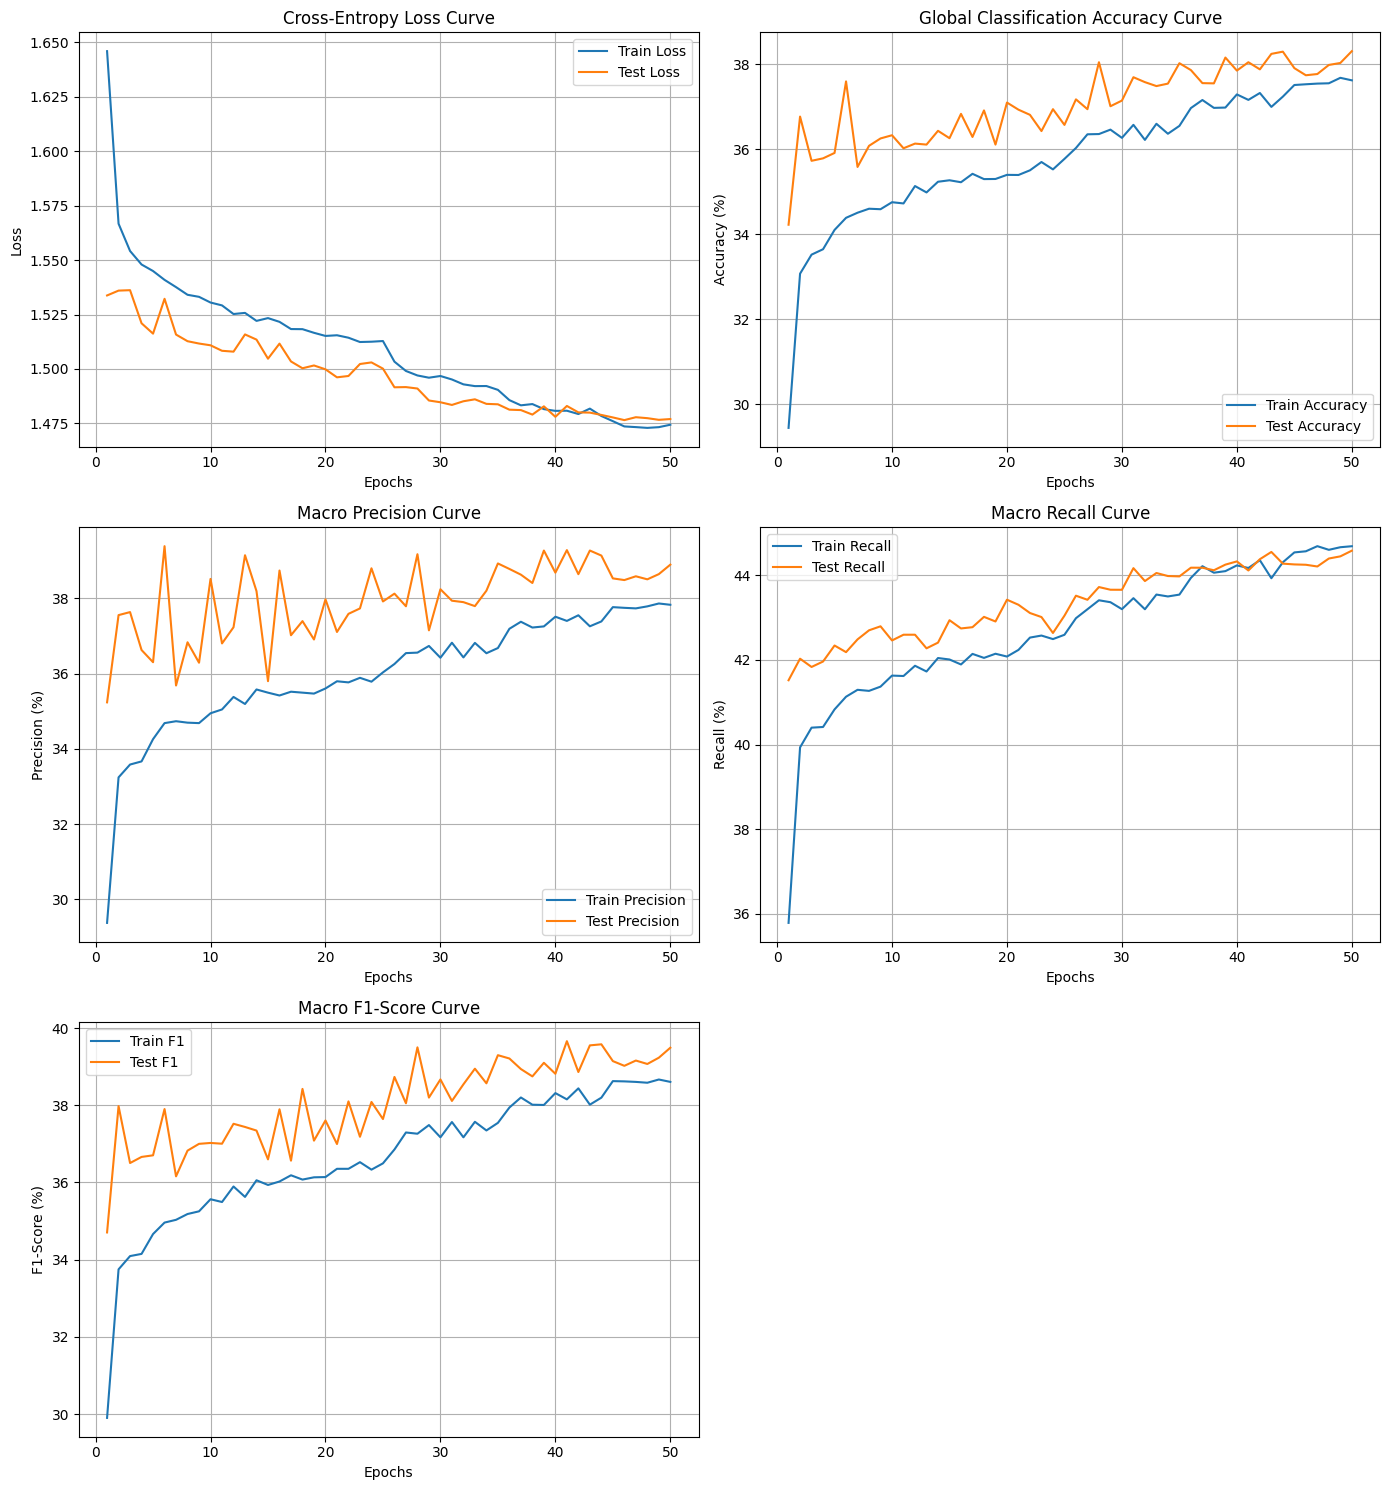

In [145]:
# ================= VISUALIZATION (3x2 Grid) =================
fig, axs = plt.subplots(3, 2, figsize=(14, 15))

# 1. Cross-Entropy Loss Curve
axs[0, 0].plot(range(1, epochs + 1), history['train_loss'], label='Train Loss')
axs[0, 0].plot(range(1, epochs + 1), history['test_loss'], label='Test Loss')
axs[0, 0].set_title('Cross-Entropy Loss Curve')
axs[0, 0].set_xlabel('Epochs')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].legend()
axs[0, 0].grid(True)

# 2. Global Accuracy Curve
axs[0, 1].plot(range(1, epochs + 1), [acc * 100 for acc in history['train_acc']], label='Train Accuracy')
axs[0, 1].plot(range(1, epochs + 1), [acc * 100 for acc in history['test_acc']], label='Test Accuracy')
axs[0, 1].set_title('Global Classification Accuracy Curve')
axs[0, 1].set_xlabel('Epochs')
axs[0, 1].set_ylabel('Accuracy (%)')
axs[0, 1].legend()
axs[0, 1].grid(True)

# 3. Macro Precision Curve
axs[1, 0].plot(range(1, epochs + 1), [p * 100 for p in history['train_precision']], label='Train Precision')
axs[1, 0].plot(range(1, epochs + 1), [p * 100 for p in history['test_precision']], label='Test Precision')
axs[1, 0].set_title('Macro Precision Curve')
axs[1, 0].set_xlabel('Epochs')
axs[1, 0].set_ylabel('Precision (%)')
axs[1, 0].legend()
axs[1, 0].grid(True)

# 4. Macro Recall Curve
axs[1, 1].plot(range(1, epochs + 1), [r * 100 for r in history['train_recall']], label='Train Recall')
axs[1, 1].plot(range(1, epochs + 1), [r * 100 for r in history['test_recall']], label='Test Recall')
axs[1, 1].set_title('Macro Recall Curve')
axs[1, 1].set_xlabel('Epochs')
axs[1, 1].set_ylabel('Recall (%)')
axs[1, 1].legend()
axs[1, 1].grid(True)

# 5. Macro F1-Score Curve (The definitive health metric for balanced classes)
axs[2, 0].plot(range(1, epochs + 1), [f * 100 for f in history['train_f1']], label='Train F1')
axs[2, 0].plot(range(1, epochs + 1), [f * 100 for f in history['test_f1']], label='Test F1')
axs[2, 0].set_title('Macro F1-Score Curve')
axs[2, 0].set_xlabel('Epochs')
axs[2, 0].set_ylabel('F1-Score (%)')
axs[2, 0].legend()
axs[2, 0].grid(True)

# Remove the empty 6th subplot to preserve symmetry
fig.delaxes(axs[2, 1])

plt.tight_layout()
plt.show()